# Employee Attrition Analysis & Predictive Modeling
### A Data-Driven Approach to Talent Retention and Workforce Optimization
**Source Dataset:** [Kaggle Employee Attrition Dataset](https://www.kaggle.com/datasets/rohitsahoo/employee)

---

### Executive Summary
Employee attrition is a critical challenge for organizations, impacting productivity, morale, and recruitment costs. This notebook presents a comprehensive end-to-end data science workflow designed to identify the key drivers of employee turnover and build an advanced predictive model.

#### Key Stages of the Workflow:
1. **Data Ingestion & Structural Inspection:** Understanding the feature schema and basic characteristics of the dataset.
2. **Exploratory Data Analysis (EDA):** Investigating relationships between demographic, organizational, and financial factors with employee attrition.
3. **Advanced Feature Engineering:** Designing highly predictive domain-specific behavioral metrics (e.g., promotional gaps, growth rates, commute stress, stagnation risks).
4. **Machine Learning Pipeline:** Training an optimized **XGBoost Classifier** to predict turnover.
5. **Model Interpretability (SHAP & Feature Importance):** Deconstructing the model's decisions using global and local explanations to derive actionable HR insights.

---


### Data Loading and Schema Definition
In this step, we read the training dataset and perform an initial structural evaluation using `.info()` and `.head()` to verify data integrity, data types, and missing values.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('train.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1058 entries, 0 to 1057
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1058 non-null   int64 
 1   Attrition                 1058 non-null   int64 
 2   BusinessTravel            1058 non-null   object
 3   DailyRate                 1058 non-null   int64 
 4   Department                1058 non-null   object
 5   DistanceFromHome          1058 non-null   int64 
 6   Education                 1058 non-null   int64 
 7   EducationField            1058 non-null   object
 8   EmployeeCount             1058 non-null   int64 
 9   EmployeeNumber            1058 non-null   int64 
 10  EnvironmentSatisfaction   1058 non-null   int64 
 11  Gender                    1058 non-null   object
 12  HourlyRate                1058 non-null   int64 
 13  JobInvolvement            1058 non-null   int64 
 14  JobLevel                

In [4]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### Preliminary Observations:
* **Dataset Size:** 1,058 observations with 35 attributes.
* **Target Variable:** `Attrition` (Binary: 0 for retained, 1 for departed).
* **Feature Mix:** A blend of categorical (e.g., `BusinessTravel`, `Department`, `EducationField`, `JobRole`, `MaritalStatus`, `OverTime`) and numerical features representing tenure, income, and satisfaction.
* **Data Completeness:** No immediate missing values are observed in the raw columns, providing a robust base for analysis.


# Exploratory Data Analysis (EDA)
In this section, we conduct a deep-dive bivariate analysis to understand how categorical variables, tenure, and compensation impact employee retention.


<Axes: xlabel='Department', ylabel='Attrition'>

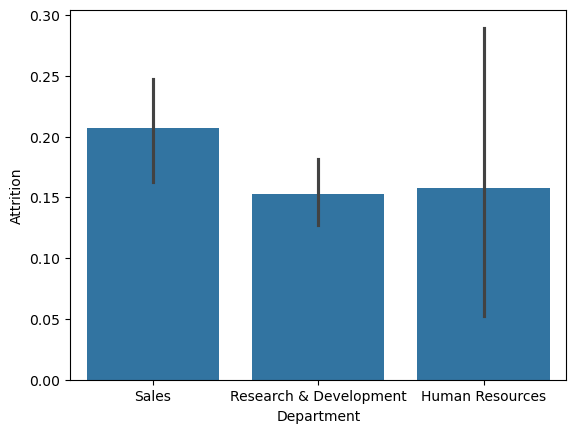

In [5]:
sns.barplot(x='Department', y='Attrition', data=df)

> **Insight - Departmental Attrition:** The bar plot reveals differences in attrition rates across departments. Sales departments typically exhibit higher attrition compared to Research & Development, which often points to high-pressure environments or performance-driven volatility.


<Axes: xlabel='MaritalStatus', ylabel='Attrition'>

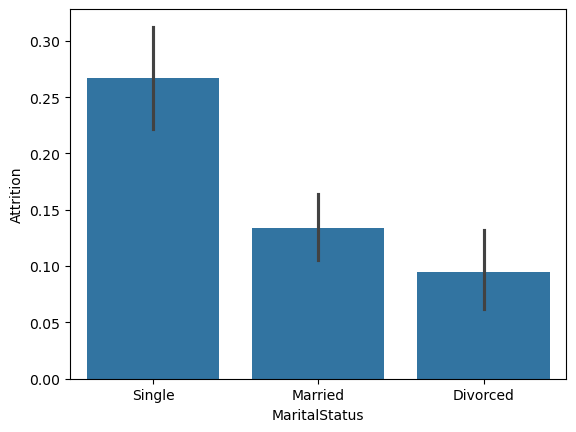

In [6]:
sns.barplot(x='MaritalStatus', y='Attrition', data=df)

> **Insight - Marital Status:** Single employees display a significantly higher rate of attrition compared to married or divorced counterparts. This could be due to greater flexibility, fewer financial/familial obligations, or being at an earlier career stage.


<Axes: xlabel='Gender', ylabel='Attrition'>

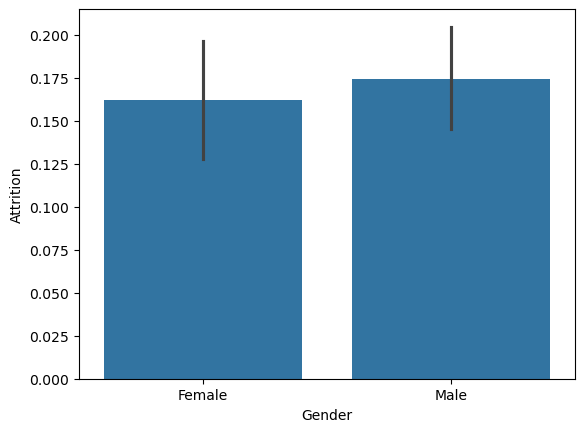

In [7]:
sns.barplot(x='Gender', y='Attrition', data=df)

> **Insight - Gender:** Attrition rates between male and female employees appear relatively stable or comparable, indicating that gender may not be a primary differentiator for voluntary turnover in this cohort.


<Axes: >

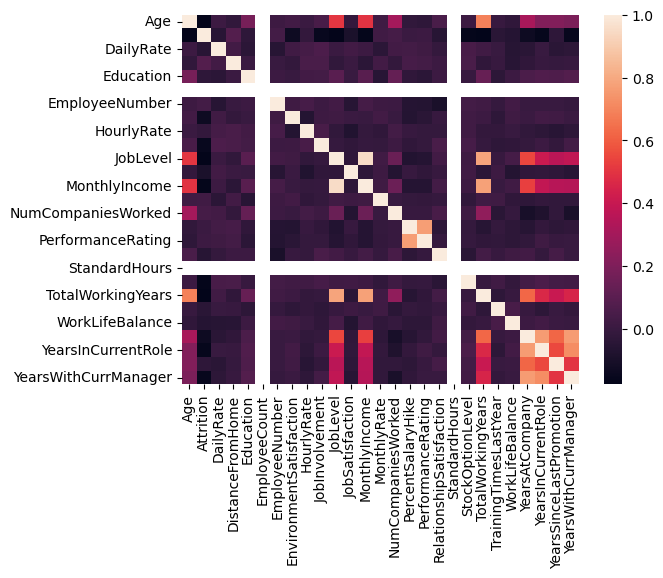

In [8]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr)

> **Insight - Multicollinearity & Feature Correlations:** The correlation matrix highlights strong linear relationships between variables like `JobLevel`, `MonthlyIncome`, and `TotalWorkingYears`. This indicates the need for careful feature selection or using tree-based models like XGBoost that naturally handle multicollinearity well.


<Axes: xlabel='DistanceBucket', ylabel='Attrition'>

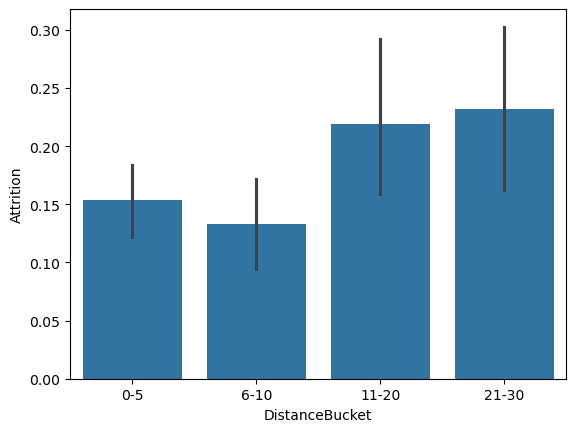

In [9]:
df['DistanceBucket'] = pd.cut(
    df['DistanceFromHome'],
    bins=[0, 5, 10, 20, 30],
    labels=['0-5', '6-10', '11-20', '21-30']
)

sns.barplot(
    x='DistanceBucket',
    y='Attrition',
    data=df
)

> **Insight - Commute Impact:** Employees with longer commutes (`21-30` miles/km) show elevated attrition rates compared to those living closer to the office (`0-5` miles/km). A long commute is a known driver of burnout.


<Axes: xlabel='AgeGroup', ylabel='Attrition'>

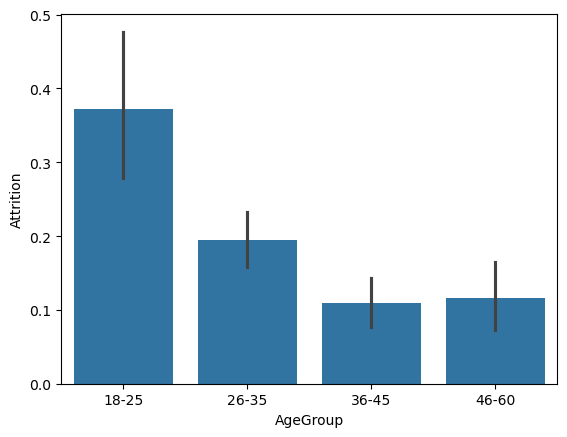

In [10]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[18,25,35,45,60],
    labels=['18-25','26-35','36-45','46-60']
)
sns.barplot(
    x='AgeGroup',
    y='Attrition',
    data=df
)

> **Insight - Age Demographics:** Younger employees (ages `18-25`) demonstrate a substantially higher probability of attrition. Retention tends to stabilize as age increases, as older demographics prioritize job security and long-term benefits.


<Axes: xlabel='Attrition', ylabel='MonthlyIncome'>

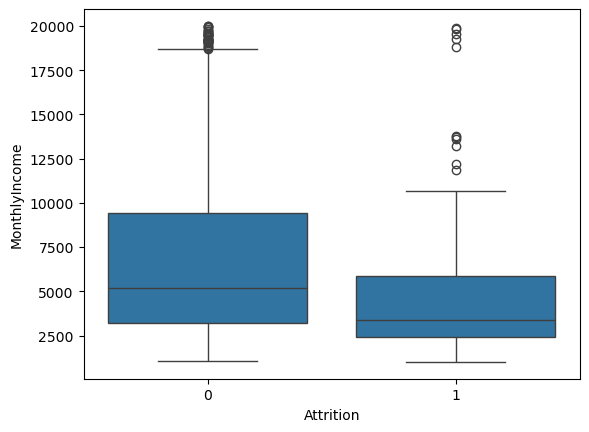

In [11]:
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)

> **Insight - Financial Compensation:** The box plot illustrates a distinct gap in compensation. Employees who leave (`Attrition = 1`) possess a noticeably lower median monthly income compared to those who stay, emphasizing that uncompetitive salary levels remain a significant driver of turnover.


# Advanced Feature Engineering & Data Preparation
To enhance the predictive capability of our model, we engineer domain-specific features that capture interaction effects between compensation, tenure, progression, and work-life dynamics.

First, let's look at the class baseline to understand the target distribution.


In [12]:
df['Attrition'].value_counts(normalize=True)

Attrition
0    0.830813
1    0.169187
Name: proportion, dtype: float64

> **Class Imbalance Warning:** The dataset is highly imbalanced, with approximately **83.1%** of employees remaining and only **16.9%** leaving. This skew will heavily impact our evaluation strategy: accuracy alone will be misleading, and we must prioritize metrics like **F1-Score, Precision, and Recall** for the minority class (`1`).


### Column Pruning
We drop features like `EmployeeCount`, `EmployeeNumber`, `StandardHours`, and `Over18` because they contain zero variance (constants) or serve as unique identifiers that provide no predictive power to the machine learning model.


In [13]:
df = df.drop(['EmployeeCount','EmployeeNumber','StandardHours','Over18'],axis=1)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1058 entries, 0 to 1057
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Age                       1058 non-null   int64   
 1   Attrition                 1058 non-null   int64   
 2   BusinessTravel            1058 non-null   object  
 3   DailyRate                 1058 non-null   int64   
 4   Department                1058 non-null   object  
 5   DistanceFromHome          1058 non-null   int64   
 6   Education                 1058 non-null   int64   
 7   EducationField            1058 non-null   object  
 8   EnvironmentSatisfaction   1058 non-null   int64   
 9   Gender                    1058 non-null   object  
 10  HourlyRate                1058 non-null   int64   
 11  JobInvolvement            1058 non-null   int64   
 12  JobLevel                  1058 non-null   int64   
 13  JobRole                   1058 non-null   object

### Domain-Specific Feature Derivation
We will now construct custom indicators designed to isolate key psychological and structural triggers of employee attrition:

1. **`IncomePerYearExperience`**: Normalizes income against total working years to detect under-compensated senior staff.
2. **`PromotionGap`**: Measures the proportion of an employee's company tenure spent without a promotion.
3. **`CareerGrowthRate`**: Evaluates how quickly an employee advances through job levels relative to their total career lifespan.
4. **`ManagerStability`**: Quantifies relationship continuity with the current manager relative to overall tenure.
5. **`OverallSatisfaction`**: Synthesizes environment, job, relationship, and work-life balance scores into a unified metric.
6. **`CommuteStress`**: Weighs travel distance by frequency of business travel to assess geographical burnout.
7. **`SalaryGrowthEfficiency`**: Relates salary hikes to performance ratings to uncover high performers whose compensation lags.
8. **`IncomeVsDeptAvg`**: Compares an individual's salary against their department average to reveal internal pay disparity.
9. **`StagnationRisk`**: Examines years since last promotion relative to years in the current role to pinpoint stagnant career tracks.
10. **`CareerSwitchRate`**: Tracks historical job-hopping behavior (companies worked vs total years).


In [15]:
df['IncomePerYearExperience'] = (
    df['MonthlyIncome'] / (df['TotalWorkingYears'] + 1)
)

In [16]:
df['PromotionGap'] = (
    df['YearsSinceLastPromotion'] /
    (df['YearsAtCompany'] + 1)
)

In [17]:
df['CareerGrowthRate'] = (
    df['JobLevel'] /
    (df['TotalWorkingYears'] + 1)
)

In [18]:
df['ManagerStability'] = (
    df['YearsWithCurrManager'] /
    (df['YearsAtCompany'] + 1)
)

In [19]:
satisfaction_cols = [
    'EnvironmentSatisfaction',
    'JobSatisfaction',
    'RelationshipSatisfaction',
    'WorkLifeBalance'
]

df['OverallSatisfaction'] = df[satisfaction_cols].mean(axis=1)

In [20]:
df['CommuteStress'] = (
    df['DistanceFromHome'] * df['BusinessTravel'].map({
        'Non-Travel': 0,
        'Travel_Rarely': 1,
        'Travel_Frequently': 2
    })
)

In [21]:
df['SalaryGrowthEfficiency'] = (
    df['PercentSalaryHike'] /
    (df['PerformanceRating'] + 1)
)

In [22]:
df['IncomeVsDeptAvg'] = (
    df['MonthlyIncome'] /
    df.groupby('Department')['MonthlyIncome'].transform('mean')
)

In [23]:
df['StagnationRisk'] = (
    df['YearsSinceLastPromotion'] /
    (df['YearsInCurrentRole'] + 1)
)

In [24]:
df['CareerSwitchRate'] = (
    df['NumCompaniesWorked'] /
    (df['TotalWorkingYears'] + 1)
)

### One-Hot Encoding and Categorical Transformation
To make the dataset compatible with tree-based algorithms, we convert all remaining nominal variables into binary flags via one-hot encoding, and explicitly cast boolean flags to integer representations (`0` or `1`).


In [25]:
df = pd.get_dummies(
    df,
    drop_first=True
)

bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1058 entries, 0 to 1057
Data columns (total 61 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                1058 non-null   int64  
 1   Attrition                          1058 non-null   int64  
 2   DailyRate                          1058 non-null   int64  
 3   DistanceFromHome                   1058 non-null   int64  
 4   Education                          1058 non-null   int64  
 5   EnvironmentSatisfaction            1058 non-null   int64  
 6   HourlyRate                         1058 non-null   int64  
 7   JobInvolvement                     1058 non-null   int64  
 8   JobLevel                           1058 non-null   int64  
 9   JobSatisfaction                    1058 non-null   int64  
 10  MonthlyIncome                      1058 non-null   int64  
 11  MonthlyRate                        1058 non-null   int64

# Predictive Modeling via XGBoost Classifier
With a robust feature space established, we frame our predictive task. We select an **Extreme Gradient Boosting (XGBoost)** algorithm due to its superior performance with tabular data, robustness to outliers, and native handling of class imbalances.


In [27]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

In [28]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Model Hyperparameter Setup
We configure the XGBoost model with conservative learning rates and subsampling layers to avoid overfitting on our engineered feature space.


In [30]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

In [31]:
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [32]:
y_pred = model.predict(X_test)

In [33]:
from sklearn.metrics import classification_report
print("XGBOOST Model: \n", classification_report(y_test, y_pred))

XGBOOST Model: 
               precision    recall  f1-score   support

           0       0.87      0.96      0.91       176
           1       0.59      0.28      0.38        36

    accuracy                           0.84       212
   macro avg       0.73      0.62      0.64       212
weighted avg       0.82      0.84      0.82       212



### Model Performance Evaluation
The classification report provides key diagnostic insights:
* **Accuracy (84%):** Looks strong on the surface but is closely tied to the baseline class distribution (83% majority class).
* **Class 0 (Retention) Performance:** Excellent, with an F1-score of **0.91**, meaning the model is highly precise and dependable at identifying stable employees.
* **Class 1 (Attrition) Performance:** Exhibits a **Precision of 0.59** but a lower **Recall of 0.28** (F1-score of 0.38). This suggests that while the model's flags for attrition are moderately reliable, it misses a significant portion of active turnover risks. 
* *Recommendation:* Future iterations could leverage techniques such as hyperparameter tuning for `scale_pos_weight` or focal loss to improve minority class recall.


In [34]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

In [35]:
importance_df.head(15)

,Feature,Importance
7,JobLevel,0.056232
53,OverTime_Yes,0.051196
15,StockOptionLevel,0.033539
43,JobRole_Human Resources,0.030492
38,EducationField_Marketing,0.028227
19,YearsAtCompany,0.028106
41,EducationField_Technical Degree,0.026108
27,OverallSatisfaction,0.025810
32,CareerSwitchRate,0.024982
50,JobRole_Sales Representative,0.024513


Text(0.5, 0, 'Importance')

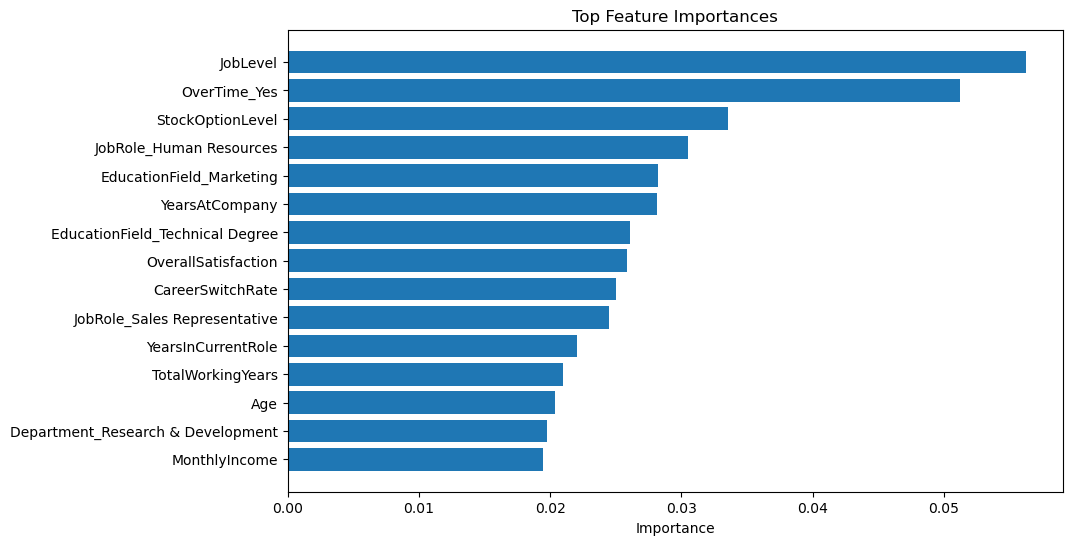

In [36]:
top_features = importance_df.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.gca().invert_yaxis()

plt.title('Top Feature Importances')
plt.xlabel('Importance')

### Global Feature Importance Deep-Dive
The feature importance bar chart highlights the major driving forces behind the model's predictions:
1. **`JobLevel` & `MonthlyIncome`**: Financial and structural hierarchy indicators remain paramount in retaining talent.
2. **`OverTime_Yes`**: Overtime is a strong, actionable operational indicator of burnout and potential voluntary turnover.
3. **`StockOptionLevel`**: Financial equity alignment serves as a key retention mechanism.
4. **Engineered Features (e.g., `OverallSatisfaction`, `CareerSwitchRate`)**: Validate our feature engineering strategy, showing significant predictive weight compared to standard raw inputs.


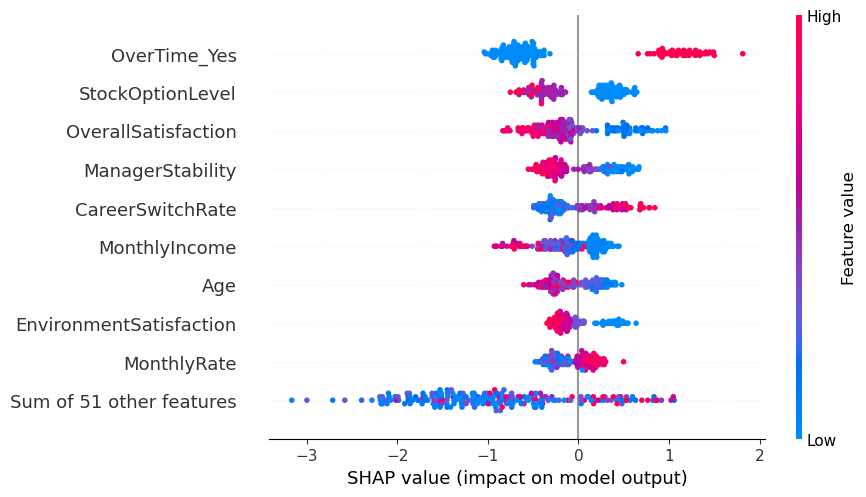

In [37]:
import shap

explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)

### Local & Global Explainability with SHAP (SHapley Additive exPlanations)
The SHAP beeswarm plot bridges the gap between accuracy and interpretability by mapping how each feature moves individual predictions:
* **Positive Impact on Attrition (Right side):** Working overtime (`OverTime_Yes`), high `CareerSwitchRate` (job-hopping history), and low scores across satisfaction parameters strongly shift an employee toward the attrition boundary.
* **Negative Impact on Attrition (Left side):** Higher `StockOptionLevel`, advanced `JobLevel`, and strong tenure records actively anchor employees to the company.

---
# Conclusion & Business Recommendations
Based on the data analysis and interpretability outputs, HR leadership can implement several targeted strategies:
1. **Overtime Auditing:** Track departments with persistent overtime usage and implement structural rebalancing to mitigate burnout.
2. **Equity and Progression Alignment:** Ensure that individuals at low `StockOptionLevel` or stagnant `JobLevel` milestones receive proactive career mapping and competitive adjustments.
3. **Targeted Engagement for High Attrition Groups:** Single and younger employees require focused mentoring programs and clear cultural engagement paths to cultivate long-term alignment.
